# Rompy hands-on: a model run from start to finish

**What this shows:** every step of a rompy model run, using a toy "model" small
enough to read in full. It is the hands-on companion to
[What rompy does](../../docs/why-rompy.md).

**Prerequisites:** Python with rompy installed. No model needs to be installed.

**You will learn:**

- how a run period, a grid and a data request describe *when*, *where* and *with what*
- what a model plugin does, by writing a tiny one
- how rompy checks a configuration before any files are written
- how `ModelRun` generates a workspace and a backend runs the model on it
- how to write a run as YAML, and how to make variants of it

**Data used:** `era5-20230101.nc`, ERA5 10 m winds off south-west Australia on
1 January 2023, in the [`data/`](data) folder.

## Setup

In [1]:
import shutil
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import yaml
from pydantic import Field, ValidationError
from rompy.logging import config as logging_config

logging_config.update(level="WARNING")  # rompy logs every step, show warnings only

DATA_DIR = Path("data")
OUT_DIR = Path("_output") / "rompy_hands_on"
shutil.rmtree(OUT_DIR, ignore_errors=True)

## 1. When and where: the run period and the grid

Every run starts with a period and a grid. These are rompy objects, shared by all
models.

In [2]:
from rompy.core.grid import RegularGrid
from rompy.core.time import TimeRange

period = TimeRange(start="2023-01-01T00", end="2023-01-01T12", interval="1h")
grid = RegularGrid(x0=114.0, y0=-33.0, dx=0.25, dy=0.25, nx=7, ny=9)
print(f"{len(period.date_range)} times from {period.start} to {period.end}")
print("grid bounding box:", [float(value) for value in grid.bbox()])

13 times from 2023-01-01 00:00:00 to 2023-01-01 12:00:00
grid bounding box: [114.0, -33.0, 115.5, -31.0]


## 2. Input data is a request

The wind dataset covers a larger area and a whole day. A data object describes the
request: which file, which variables and what the coordinates are called. Nothing
is read until the data is needed.

In [3]:
from rompy.core.data import DataGrid
from rompy.core.filters import Filter
from rompy.core.source import SourceFile

wind = DataGrid(
    id="wind",
    source=SourceFile(uri=DATA_DIR / "era5-20230101.nc"),
    variables=["u10", "v10"],
    coords={"x": "longitude", "y": "latitude", "t": "time"},
    filter=Filter(sort={"coords": ["latitude"]}),  # ERA5 latitudes run north to south
    buffer=0.25,
)

`get()` resolves the request for a grid and period: it selects the part of the
dataset that covers them and writes it to a file.

In [4]:
OUT_DIR.mkdir(parents=True)
source = xr.open_dataset(DATA_DIR / "era5-20230101.nc")
extracted = xr.open_dataset(wind.get(OUT_DIR, grid=grid, time=period))
print("source:   ", dict(source.sizes))
print("extracted:", dict(extracted.sizes))

source:    {'time': 25, 'latitude': 25, 'longitude': 13}
extracted: {'time': 13, 'latitude': 11, 'longitude': 9}


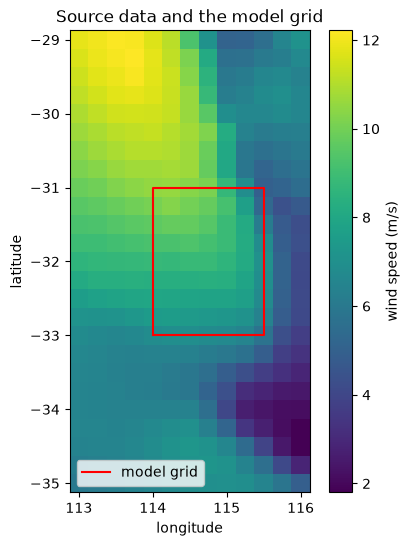

In [5]:
fig, ax = plt.subplots(figsize=(5, 6))
speed = (source.u10**2 + source.v10**2) ** 0.5
speed.isel(time=0).plot(ax=ax, cmap="viridis", cbar_kwargs={"label": "wind speed (m/s)"})
x0, y0, x1, y1 = grid.bbox()
ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], color="red", label="model grid")
ax.set_aspect("equal")
ax.legend(loc="lower left")
ax.set_title("Source data and the model grid");

## 3. A model plugin in miniature

Our toy model is the script [`wind_stress_model.py`](wind_stress_model.py). Like a
real model executable, it knows nothing about rompy: it reads a settings file,
`params.txt`, and a wind file, and writes the wind stress on the sea surface to
`output.csv`.

A model plugin describes such a model to rompy. Real plugins (rompy-swan,
rompy-xbeach, rompy-schism) are larger, but follow the same pattern:

- **fields** hold the model settings, with types and allowed ranges;
- **`__call__`** is run by `ModelRun` to fetch the data and write the model's files;
- **`model_type`** names the plugin. Installed plugins register theirs (for example
  `xbeach`) so that `ModelRun` and YAML files can find them. Our toy plugin is not
  installed, so it keeps rompy's generic type, `base`.

In [6]:
from rompy.core.config import BaseConfig


class WindStressConfig(BaseConfig):
    """Configuration of the toy wind stress model."""

    grid: RegularGrid
    wind: DataGrid
    drag_coefficient: float = Field(1.2e-3, gt=0, le=5e-3, description="Cd")
    air_density: float = Field(1.225, gt=0, description="Air density (kg/m3)")

    def __call__(self, runtime):
        workspace = Path(runtime.staging_dir)
        wind_file = self.wind.get(workspace, grid=self.grid, time=runtime.period)
        params = {
            "wind_file": wind_file.name,
            "u_var": "u10",
            "v_var": "v10",
            "time_var": self.wind.coords.t,
            "drag_coefficient": self.drag_coefficient,
            "air_density": self.air_density,
        }
        lines = [f"{key} = {value}" for key, value in params.items()]
        (workspace / "params.txt").write_text("\n".join(lines) + "\n")
        return self

    def render(self, context, output_dir):
        """All files are written in __call__, so there is no template to render."""

## 4. Checked as you build it

The plugin declares that the drag coefficient must be positive and at most 0.005.
A value outside that range is rejected when the object is created, long before a
model would read it.

In [7]:
try:
    WindStressConfig(grid=grid, wind=wind, drag_coefficient=0.012)
except ValidationError as err:
    print(err)

1 validation error for WindStressConfig
drag_coefficient
  Input should be less than or equal to 0.005 [type=less_than_equal, input_value=0.012, input_type=float]
    For further information visit https://errors.pydantic.dev/2.13/v/less_than_equal


In [8]:
config = WindStressConfig(grid=grid, wind=wind)
config.drag_coefficient

0.0012

## 5. Generate the workspace

`ModelRun` brings the period, an output directory and the configuration together.
Calling it generates the workspace: here, the cropped wind file and `params.txt`.

In [9]:
from rompy.model import ModelRun

run = ModelRun(run_id="base", period=period, output_dir=OUT_DIR, config=config)
workspace = Path(run())
print(sorted(p.name for p in workspace.iterdir()))
print((workspace / "params.txt").read_text())

['params.txt', 'wind.nc']
wind_file = wind.nc
u_var = u10
v_var = v10
time_var = time
drag_coefficient = 0.0012
air_density = 1.225



## 6. Run the model with a backend

A backend runs the model on a generated workspace. `LocalConfig` runs a command in
the workspace on this machine; `DockerConfig` would run it in a container instead,
without changing the configuration.

In [10]:
from rompy.backends import LocalConfig

MODEL = Path("wind_stress_model.py").resolve()
backend = LocalConfig(command=f"{sys.executable} {MODEL}")
run.run(backend, workspace_dir=workspace)

True

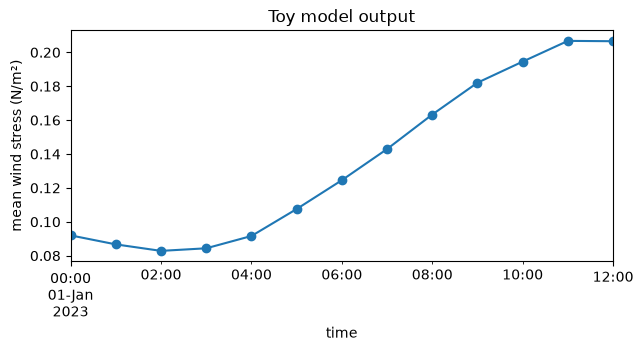

In [11]:
output = pd.read_csv(workspace / "output.csv", index_col=0, parse_dates=True)
ax = output.mean_stress.plot(figsize=(7, 3), marker="o")
ax.set_ylabel("mean wind stress (N/m²)")
ax.set_title("Toy model output");

## 7. The run as a YAML file

The whole run is data, so it can be written to a YAML file, versioned and shared.
Only the values that were set are written; everything else keeps its default.

In [12]:
run_dict = run.model_dump(mode="json", exclude_unset=True, serialize_as_any=True)
run_yaml = yaml.safe_dump(run_dict, sort_keys=False)
print(run_yaml)

run_id: base
period:
  start: '2023-01-01T00:00:00'
  end: '2023-01-01T12:00:00'
  interval: PT1H
  include_end: true
output_dir: _output/rompy_hands_on
config:
  grid:
    x0: 114.0
    y0: -33.0
    dx: 0.25
    dy: 0.25
    nx: 7
    ny: 9
  wind:
    id: wind
    source:
      uri: data/era5-20230101.nc
    filter:
      sort:
        coords:
        - latitude
    variables:
    - u10
    - v10
    coords:
      t: time
      x: longitude
      y: latitude
    buffer: 0.25



With an installed plugin, a file like this loads back into a checked `ModelRun`,
in Python or with `rompy generate`. Our toy plugin exists only in this notebook, so
[XBeach tutorial 7](../xbeach/tutorial/07_yaml_and_cli.ipynb) shows that round trip
with a real plugin.

## 8. Variants

A variant is a copy of the configuration with one change, generated as a new run
with its own run id. Here we compare three drag coefficients.

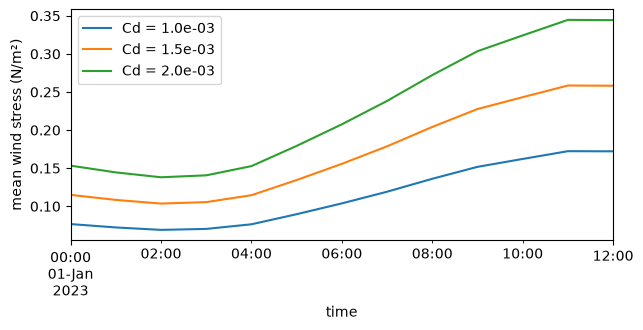

In [13]:
fig, ax = plt.subplots(figsize=(7, 3))
for drag in [1.0e-3, 1.5e-3, 2.0e-3]:
    variant = ModelRun(
        run_id=f"cd_{drag:.1e}",
        period=period,
        output_dir=OUT_DIR,
        config=config.model_copy(update={"drag_coefficient": drag}),
    )
    variant_workspace = variant()
    variant.run(backend, workspace_dir=variant_workspace)
    result = pd.read_csv(Path(variant_workspace) / "output.csv", index_col=0, parse_dates=True)
    result.mean_stress.plot(ax=ax, label=f"Cd = {drag:.1e}")
ax.set_ylabel("mean wind stress (N/m²)")
ax.legend();

In [14]:
sorted(p.name for p in OUT_DIR.iterdir() if p.is_dir())

['base', 'cd_1.0e-03', 'cd_1.5e-03', 'cd_2.0e-03']

`model_copy(update=...)` does not re-run validation, so pass values you know are
valid, or rebuild the object (`WindStressConfig(**...)`) to check them.

## Summary

- `TimeRange` and a grid say when and where; data objects say what data is needed,
  and rompy extracts only that.
- A model plugin turns checked settings into the model's own files.
- `ModelRun` generates the workspace; a backend runs the model on it.
- A run can be written as YAML and copied into variants.

**Next:** follow a learning tutorial to see the same steps with a real model:
[XBeach](../xbeach/tutorial/01_first_model.ipynb) or
[SWAN](../swan/tutorial_01_rompy_orientation.ipynb).